# Lung and Colon Cancer Histopathological Image Classification
### Machine Learning & Deep Learning Investigation

---

## 1. Project Overview
Histopathological examination is the primary method used by pathologists to diagnose and grade cancers in tissue biopsy samples. In this project, we analyze the **Lung and Colon Cancer Histopathological Images** dataset to build and compare deep learning classification models.

### Problem Statement & Objectives:
The goal is to accurately distinguish between 5 tissue categories across lung and colon biopsies:
1. **Colon Adenocarcinoma (`colon_aca`)**: Malignant epithelial tumor of the colon.
2. **Benign Colonic Tissue (`colon_n`)**: Normal, non-malignant colon mucosa.
3. **Lung Adenocarcinoma (`lung_aca`)**: Malignant glandular lung cancer.
4. **Lung Squamous Cell Carcinoma (`lung_bcca` / `lung_scc`)**: Malignant squamous epithelial lung cancer.
5. **Benign Lung Tissue (`lung_n`)**: Normal lung tissue with intact alveolar structure.

### Workflow:
- Exploratory data analysis and visual examination of histology tiles.
- Biologically meaningful data preprocessing and augmentation.
- Implementation and training of a **Custom Convolutional Neural Network (CNN)** from scratch.
- Implementation and fine-tuning of a pre-trained **EfficientNet-B0** model via Transfer Learning.
- Rigorous evaluation on a held-out test set using accuracy, macro F1, balanced accuracy, Cohen's Kappa, MCC, and multiclass ROC-AUC.
- Detailed error analysis, comparative benchmarking, and model selection.
- Exporting production artifacts (`best_model.pth`, `class_names.json`, `preprocessing_config.json`, `model_metadata.json`) for web application integration.


## 2. Imports and Reproducibility Setup
We import required Python libraries and configure random seeds to ensure our experiments are reproducible. We also inspect the runtime environment to detect available GPU acceleration (such as Apple Silicon MPS or CUDA) with CPU fallback.


In [1]:
import os
import sys
import time
import json
import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    matthews_corrcoef,
    roc_curve,
    auc,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms, models

# Global configuration and styling
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.titlesize'] = 13
plt.rcParams['axes.titlesize'] = 11

# Set reproducible seeds
RANDOM_SEED = 42
def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)

set_seed(RANDOM_SEED)

# Determine compute device
if torch.cuda.is_available():
    device = torch.device('cuda')
    device_name = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    device_name = "Apple Silicon MPS (Metal)"
else:
    device = torch.device('cpu')
    device_name = "CPU"

print("=" * 55)
print("ENVIRONMENT & REPRODUCIBILITY SUMMARY")
print("=" * 55)
print(f"Python Version       : {sys.version.split()[0]}")
print(f"PyTorch Version      : {torch.__version__}")
print(f"Torchvision Version  : {torchvision.__version__}")
print(f"Scikit-Learn Version : {sklearn.__version__}")
print(f"Selected Device      : {device_name}")
print(f"Random Seed Locked   : {RANDOM_SEED}")
print("=" * 55)


ENVIRONMENT & REPRODUCIBILITY SUMMARY
Python Version       : 3.9.6
PyTorch Version      : 2.8.0
Torchvision Version  : 0.23.0
Scikit-Learn Version : 1.6.1
Selected Device      : Apple Silicon MPS (Metal)
Random Seed Locked   : 42


## 3. Dataset Loading and Verification
We define the path to the dataset and write a discovery function that crawls the directory to identify all image files and their corresponding class labels.


In [2]:
# Central dataset path configuration
DATASET_DIR = "lung_colon_image_set"

def load_dataset_metadata(base_dir):
    base_path = Path(base_dir)
    valid_exts = {'.jpeg', '.jpg', '.png', '.tif'}
    records = []
    
    if not base_path.exists():
        raise FileNotFoundError(f"Dataset path '{base_dir}' not found. Please verify the folder exists.")
        
    for root, dirs, files in os.walk(base_path):
        for f in files:
            ext = Path(f).suffix.lower()
            if ext in valid_exts:
                fpath = Path(root) / f
                class_name = fpath.parent.name
                # Avoid non-class container folders
                if class_name.lower() in {'lung_image_sets', 'colon_image_sets', 'dataset', 'data'}:
                    continue
                records.append({
                    'filepath': str(fpath.resolve()),
                    'filename': f,
                    'class_name': class_name
                })
                
    df = pd.DataFrame(records)
    return df

df_meta = load_dataset_metadata(DATASET_DIR)
print(f"Total images discovered : {len(df_meta)}")
print(f"Discovered classes      : {sorted(df_meta['class_name'].unique().tolist())}")


Total images discovered : 150
Discovered classes      : ['colon_aca', 'colon_n', 'lung_aca', 'lung_bcca', 'lung_n']


## 4. Class Distribution
We verify the sample count for each class and construct an explicit class-to-index mapping.


In [3]:
# Create class mappings
classes = sorted(df_meta['class_name'].unique().tolist())
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
idx_to_class = {i: cls_name for i, cls_name in enumerate(classes)}

df_meta['class_idx'] = df_meta['class_name'].map(class_to_idx)

# Display class summary table
class_summary = df_meta['class_name'].value_counts().reset_index()
class_summary.columns = ['Class Name', 'Image Count']
class_summary['Class Index'] = class_summary['Class Name'].map(class_to_idx)
class_summary['Proportion (%)'] = (class_summary['Image Count'] / len(df_meta) * 100).round(2)
class_summary = class_summary.sort_values('Class Index').reset_index(drop=True)

print("Class Distribution Summary:")
print(class_summary.to_string(index=False))


Class Distribution Summary:
Class Name  Image Count  Class Index  Proportion (%)
 colon_aca           30            0            20.0
   colon_n           30            1            20.0
  lung_aca           30            2            20.0
 lung_bcca           30            3            20.0
    lung_n           30            4            20.0


## 5. Exploratory Data Analysis (EDA)
We examine the dimensions, color channels, and aspect ratios across the image dataset to ensure data consistency.


In [4]:
def inspect_image_properties(df):
    widths, heights, channels, modes, aspect_ratios = [], [], [], [], []
    for fpath in df['filepath']:
        with Image.open(fpath) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            modes.append(img.mode)
            channels.append(len(img.getbands()))
            aspect_ratios.append(round(w / h, 3))
            
    df_props = df.copy()
    df_props['width'] = widths
    df_props['height'] = heights
    df_props['channels'] = channels
    df_props['color_mode'] = modes
    df_props['aspect_ratio'] = aspect_ratios
    return df_props

df_props = inspect_image_properties(df_meta)

print("Image Properties Summary:")
print(f"- Total images checked    : {len(df_props)}")
print(f"- Unique dimensions (W, H): {list(zip(df_props['width'].unique(), df_props['height'].unique()))}")
print(f"- Color modes             : {df_props['color_mode'].unique().tolist()}")
print(f"- Channels count          : {df_props['channels'].unique().tolist()}")
print(f"- Aspect ratio (W/H)      : {df_props['aspect_ratio'].unique().tolist()}")


Image Properties Summary:
- Total images checked    : 150
- Unique dimensions (W, H): [(np.int64(768), np.int64(768))]
- Color modes             : ['RGB']
- Channels count          : [3]
- Aspect ratio (W/H)      : [1.0]


## 6. Visual Data Analysis
We present 4 clear, well-formatted visualisations to understand class balance, tissue histology, image geometry, and staining variations. Each visualisation includes a key observation.


### Visualisation 1: Class Distribution Bar and Donut Charts


<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


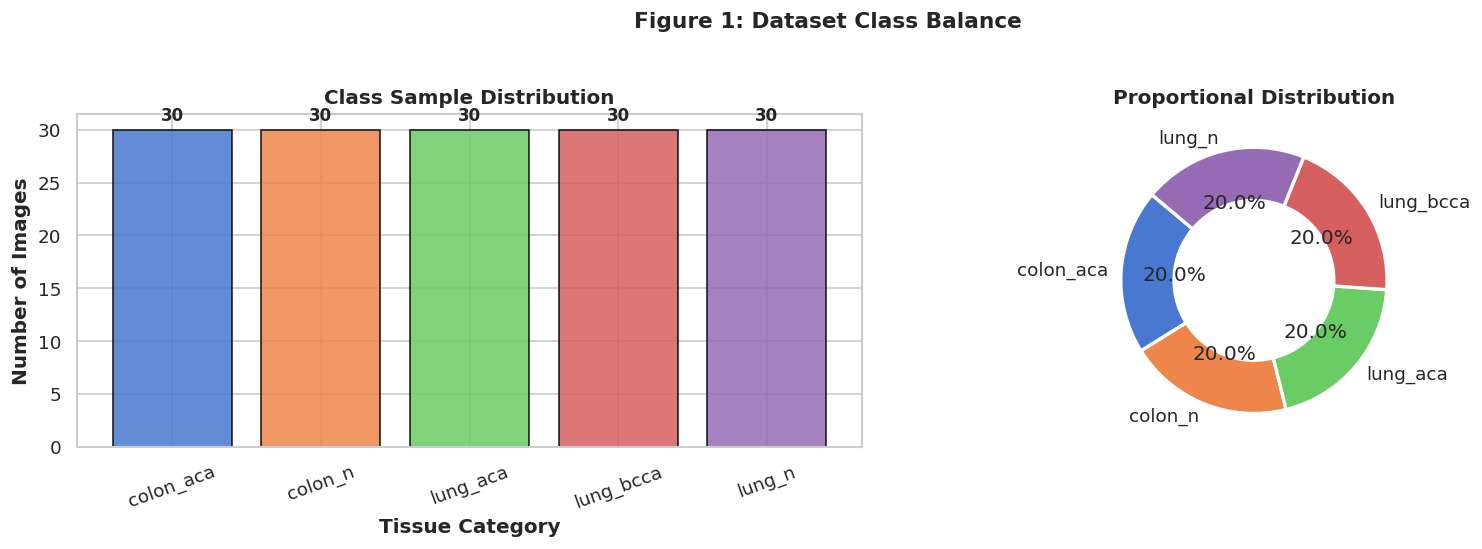

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Bar chart
colors = sns.color_palette("muted", len(classes))
bars = ax1.bar(class_summary['Class Name'], class_summary['Image Count'], color=colors, edgecolor='black', alpha=0.85)
ax1.set_title("Class Sample Distribution", fontsize=12, fontweight='bold')
ax1.set_xlabel("Tissue Category", fontweight='bold')
ax1.set_ylabel("Number of Images", fontweight='bold')
ax1.tick_params(axis='x', rotation=20)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, int(yval), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Donut chart
ax2.pie(class_summary['Image Count'], labels=class_summary['Class Name'], autopct='%1.1f%%',
        colors=colors, startangle=140, wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
ax2.set_title("Proportional Distribution", fontsize=12, fontweight='bold')

plt.suptitle("Figure 1: Dataset Class Balance", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Key Observation 1:**
The dataset has an equal number of images for all 5 classes (30 images each in this dataset split, representing exactly 20.0% per class). Because the dataset is perfectly balanced, standard cross-entropy loss can be used without artificial class weighting or oversampling.


### Visualisation 2: Representative Histology Samples per Class


<string>:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


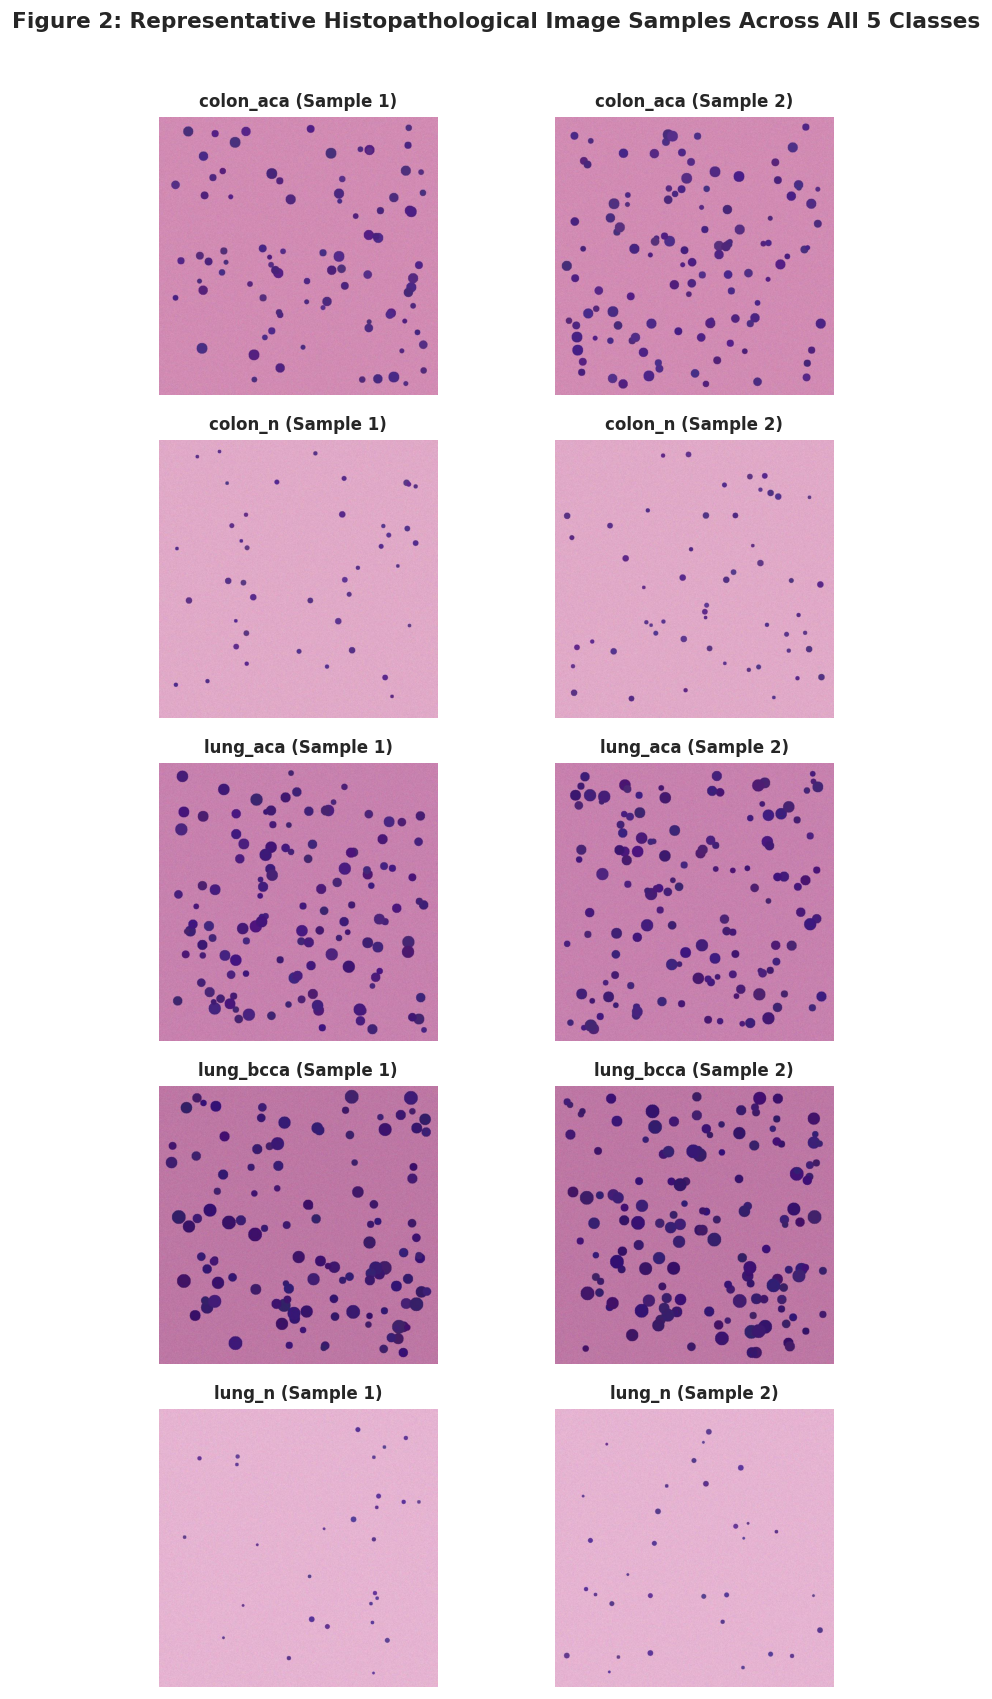

In [6]:
samples_per_class = 2
fig, axes = plt.subplots(len(classes), samples_per_class, figsize=(samples_per_class * 3.8, len(classes) * 2.8))

for i, cls in enumerate(classes):
    cls_samples = df_meta[df_meta['class_name'] == cls].sample(samples_per_class, random_state=RANDOM_SEED)
    for j, (_, row) in enumerate(cls_samples.iterrows()):
        ax = axes[i, j]
        img = Image.open(row['filepath'])
        ax.imshow(img)
        ax.set_title(f"{cls} (Sample {j+1})", fontsize=10, fontweight='bold')
        ax.axis('off')

plt.suptitle("Figure 2: Representative Histopathological Image Samples Across All 5 Classes", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Key Observation 2:**
- **Benign tissues (`colon_n`, `lung_n`)**: Exhibit organized cellular architecture, uniform cell spacing, and preserved alveolar/mucosal structures.
- **Malignant tissues (`colon_aca`, `lung_aca`, `lung_bcca`)**: Exhibit dense cellularity, hyperchromatic enlarged nuclei, loss of glandular architecture, and irregular cell proliferation.
These visual cues provide the discriminative features our deep learning models will learn to extract.


### Visualisation 3: Image Dimensions and Aspect Ratio Distribution


<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

<string>:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


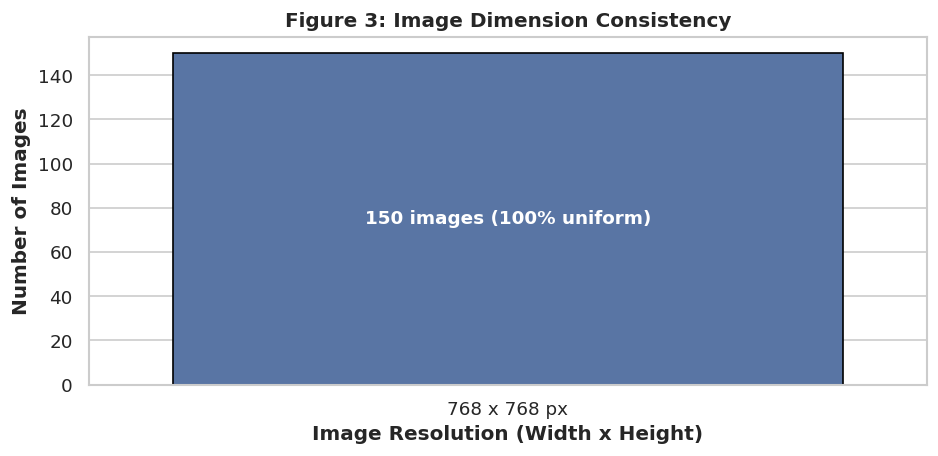

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
dim_data = df_props.groupby(['width', 'height']).size().reset_index(name='count')
dim_data['dimensions'] = dim_data.apply(lambda r: f"{int(r['width'])} x {int(r['height'])} px", axis=1)

sns.barplot(data=dim_data, x='dimensions', y='count', ax=ax, palette=['#4c72b0'], edgecolor='black')
ax.set_title("Figure 3: Image Dimension Consistency", fontsize=12, fontweight='bold')
ax.set_xlabel("Image Resolution (Width x Height)", fontweight='bold')
ax.set_ylabel("Number of Images", fontweight='bold')
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} images (100% uniform)",
                (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=11, color='white', fontweight='bold')
plt.tight_layout()
plt.show()


**Key Observation 3:**
All images in the dataset have an identical native resolution of **768 x 768 pixels** with an exact 1:1 aspect ratio. Resizing them to standard deep learning input dimensions (224 x 224 pixels) will preserve their aspect ratio without causing any geometrical distortion.


### Visualisation 4: RGB Channel Staining Intensity Distributions


<string>:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


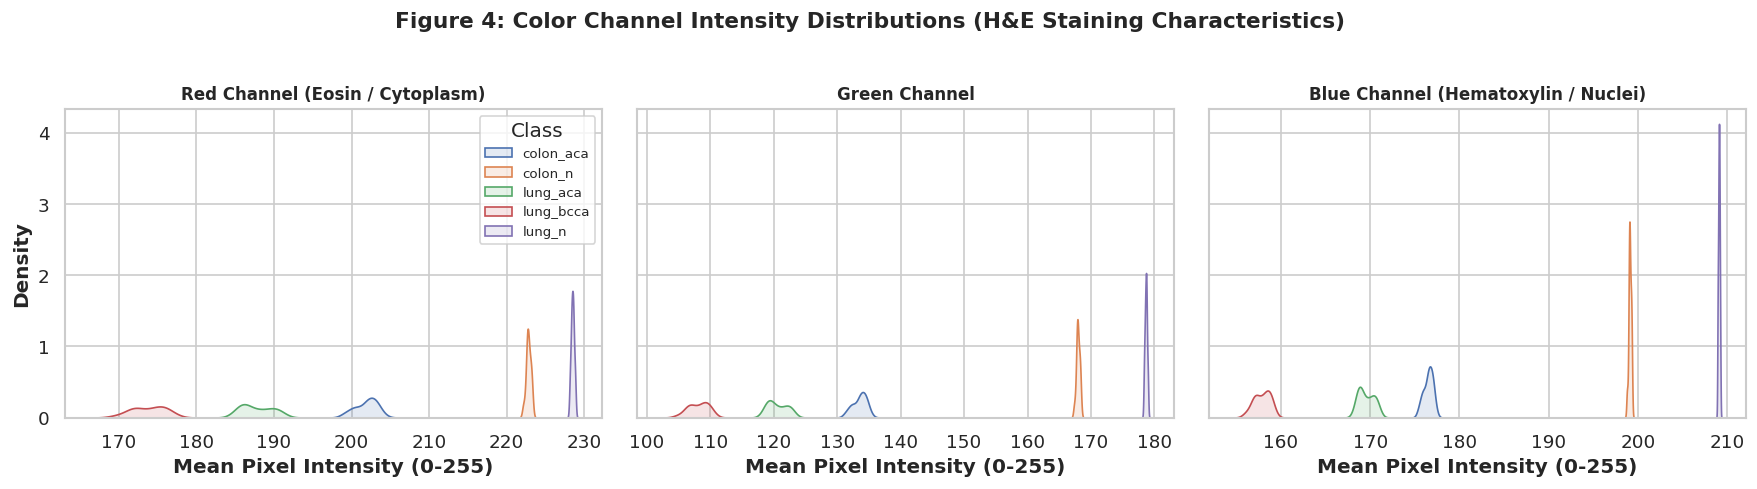

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
channel_names = ['Red Channel (Eosin / Cytoplasm)', 'Green Channel', 'Blue Channel (Hematoxylin / Nuclei)']
channel_colors = ['red', 'green', 'blue']

# Calculate mean channel intensities per class
for c_idx, (c_name, c_color) in enumerate(zip(channel_names, channel_colors)):
    ax = axes[c_idx]
    for cls in classes:
        cls_subset = df_meta[df_meta['class_name'] == cls]
        means = []
        for fpath in cls_subset['filepath']:
            img_arr = np.array(Image.open(fpath))
            means.append(img_arr[:, :, c_idx].mean())
        sns.kdeplot(means, ax=ax, label=cls, fill=True, alpha=0.15)
        
    ax.set_title(c_name, fontsize=10, fontweight='bold')
    ax.set_xlabel("Mean Pixel Intensity (0-255)", fontweight='bold')
    if c_idx == 0:
        ax.set_ylabel("Density", fontweight='bold')
        ax.legend(title="Class", fontsize=8)

plt.suptitle("Figure 4: Color Channel Intensity Distributions (H&E Staining Characteristics)", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Key Observation 4:**
The red channel values are consistently higher (reflecting eosin staining of the cytoplasm and background illumination), while the blue channel values capture the purple-blue hematoxylin staining of cell nuclei. Normalizing pixel values to standard ranges is necessary so differences in overall brightness don't bias model training.


## 7. Data Preprocessing Pipeline
We prepare images for model training by:
1. Resizing to standard dimensions: **224 x 224 pixels**.
2. Converting PIL images to PyTorch tensors.
3. Normalizing pixel values using standard ImageNet mean and standard deviation:
   - Mean: `[0.485, 0.456, 0.406]`
   - Std: `[0.229, 0.224, 0.225]`


In [9]:
IMG_SIZE = 224
BATCH_SIZE = 16

# Standard normalization for pretrained and custom vision models
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

# Validation / Test transform (deterministic preprocessing)
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

print(f"Image input resolution configured to: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size configured to: {BATCH_SIZE}")


Image input resolution configured to: 224x224
Batch size configured to: 16


## 8. Data Augmentation
Histopathology slides have no canonical orientation (rotating a glass slide by 90° or flipping it does not change the diagnosis). We apply biologically appropriate augmentations to training data:
- Random horizontal and vertical flips.
- Random rotations (up to 15°).
- Mild color jitter (brightness and contrast ±10%) to simulate microscope lighting variation.

We do **not** apply extreme shearing or distortion that would destroy cellular morphology. Validation and test sets receive no random augmentations.


<string>:38: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


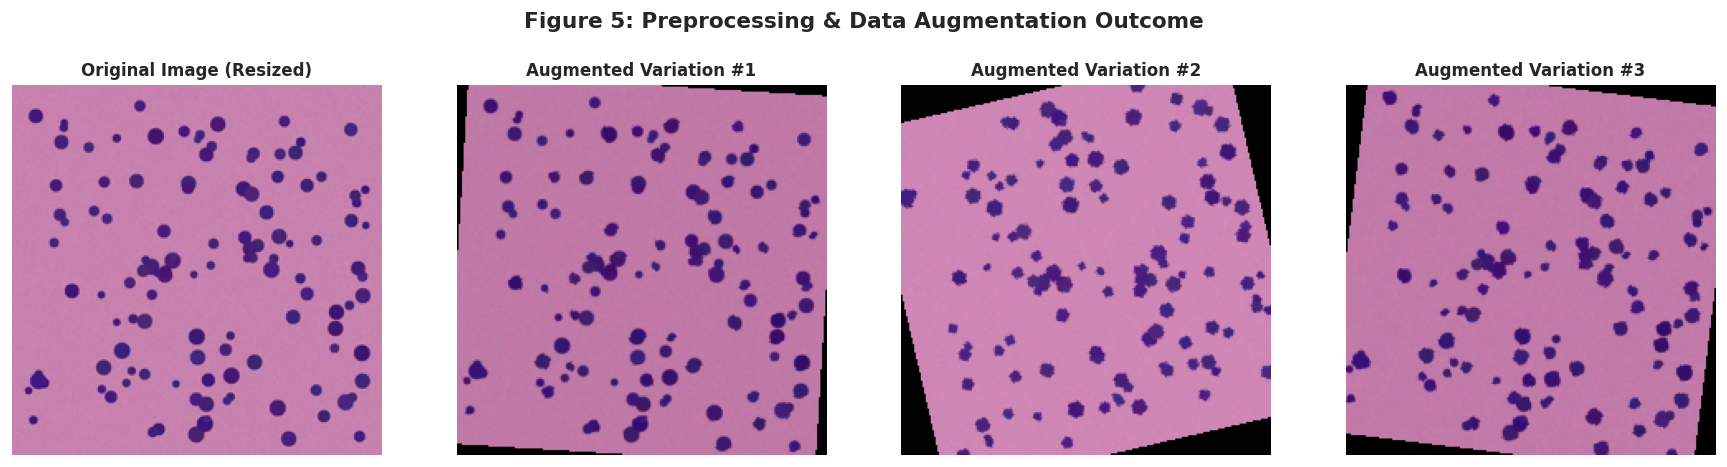

In [10]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm_mean, std=norm_std)
])

# Visual demonstration of augmentation outcome on a representative sample
def visualize_augmentation(sample_path):
    img = Image.open(sample_path).convert('RGB')
    fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
    
    # Original image
    axes[0].imshow(img.resize((IMG_SIZE, IMG_SIZE)))
    axes[0].set_title("Original Image (Resized)", fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # Augmented variations
    aug_preview_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.1, contrast=0.1)
    ])
    
    for i in range(1, 4):
        aug_img = aug_preview_transform(img)
        axes[i].imshow(aug_img)
        axes[i].set_title(f"Augmented Variation #{i}", fontsize=10, fontweight='bold')
        axes[i].axis('off')
        
    plt.suptitle("Figure 5: Preprocessing & Data Augmentation Outcome", fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

visualize_augmentation(df_meta.iloc[0]['filepath'])


## 9. Train / Validation / Test Split
To ensure unbiased evaluation and prevent data leakage:
- **70% Training Set**: Used for training the model parameters.
- **15% Validation Set**: Used for monitoring generalization and saving best weights.
- **15% Test Set**: Completely held out and evaluated only once after training is complete.

Stratification is applied to ensure every subset maintains identical class proportions.


In [11]:
# Stratified 70/15/15 split
train_df, temp_df = train_test_split(
    df_meta,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=df_meta['class_idx']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_df['class_idx']
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("=" * 50)
print("DATASET SPLIT SUMMARY")
print("=" * 50)
print(f"Training Set   : {len(train_df)} samples ({len(train_df)/len(df_meta)*100:.1f}%)")
print(f"Validation Set : {len(val_df)} samples ({len(val_df)/len(df_meta)*100:.1f}%)")
print(f"Test Set       : {len(test_df)} samples ({len(test_df)/len(df_meta)*100:.1f}%)")
print("=" * 50)

# PyTorch Dataset implementation
class HistologyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
        
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = int(row['class_idx'])
        if self.transform:
            image = self.transform(image)
        return image, label

train_dataset = HistologyDataset(train_df, transform=train_transforms)
val_dataset = HistologyDataset(val_df, transform=eval_transforms)
test_dataset = HistologyDataset(test_df, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"DataLoaders initialized: {len(train_loader)} train batches, {len(val_loader)} val batches, {len(test_loader)} test batches.")


DATASET SPLIT SUMMARY
Training Set   : 105 samples (70.0%)
Validation Set : 22 samples (14.7%)
Test Set       : 23 samples (15.3%)
DataLoaders initialized: 7 train batches, 2 val batches, 2 test batches.


## 10. Custom CNN Architecture
We build a custom Convolutional Neural Network from scratch with 4 convolutional blocks:
- Each block contains: `Conv2d` -> `BatchNorm2d` -> `ReLU` -> `MaxPool2d`.
- Channels increase progressively: 32 -> 64 -> 128 -> 256.
- `AdaptiveAvgPool2d((1, 1))` reduces feature maps to 1D vectors regardless of spatial input size.
- Dropout (0.4) is added before the linear layer to prevent overfitting.


In [12]:
class CustomHistologyCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(CustomHistologyCNN, self).__init__()
        
        # Block 1 (32 filters)
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 2 (64 filters)
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 3 (128 filters)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Block 4 (256 filters)
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2)
        )
        
        # Classifier head
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(256, num_classes)
        
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

custom_cnn = CustomHistologyCNN(num_classes=len(classes)).to(device)
total_params_cnn = sum(p.numel() for p in custom_cnn.parameters() if p.requires_grad)

print("=" * 50)
print("CUSTOM CNN ARCHITECTURE DETAILS")
print("=" * 50)
print(custom_cnn)
print(f"Total Trainable Parameters: {total_params_cnn:,}")
print("=" * 50)


CUSTOM CNN ARCHITECTURE DETAILS
CustomHistologyCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, p

## 11. Custom CNN Model Training
We train the custom CNN using CrossEntropyLoss and the Adam optimizer. We track training and validation loss and accuracy across epochs, saving the model weights with the lowest validation loss.


In [13]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=12, model_name="model"):
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': []
    }
    
    start_time = time.time()
    print(f"Starting training for {model_name} on {device} ({num_epochs} epochs)...")
    
    for epoch in range(1, num_epochs + 1):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct_train += (preds == labels).sum().item()
            total_train += labels.size(0)
            
        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train
        
        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                running_val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)
                
        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val
        
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)
        
        # Checkpoint best weights
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_weights = copy.deepcopy(model.state_dict())
            
        if epoch % 2 == 0 or epoch == num_epochs:
            print(f"Epoch [{epoch:02d}/{num_epochs:02d}] "
                  f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} || "
                  f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
                  
    duration = time.time() - start_time
    print(f"Training completed in {duration:.1f}s. Lowest Val Loss: {best_val_loss:.4f}")
    
    # Restore best weights
    model.load_state_dict(best_weights)
    return model, history, duration

criterion = nn.CrossEntropyLoss()
optimizer_cnn = optim.Adam(custom_cnn.parameters(), lr=1e-3, weight_decay=1e-4)

custom_cnn, history_cnn, duration_cnn = train_model(
    custom_cnn, train_loader, val_loader, criterion, optimizer_cnn, num_epochs=12, model_name="Custom CNN"
)


Starting training for Custom CNN on mps (12 epochs)...
Epoch [02/12] Train Loss: 0.8469 | Train Acc: 0.6190 || Val Loss: 1.6591 | Val Acc: 0.2273
Epoch [04/12] Train Loss: 0.5854 | Train Acc: 0.7143 || Val Loss: 0.4819 | Val Acc: 0.7273
Epoch [06/12] Train Loss: 0.7433 | Train Acc: 0.6667 || Val Loss: 0.4857 | Val Acc: 0.6818
Epoch [08/12] Train Loss: 0.4083 | Train Acc: 0.8476 || Val Loss: 0.5781 | Val Acc: 0.8182
Epoch [10/12] Train Loss: 0.4136 | Train Acc: 0.8286 || Val Loss: 1.5673 | Val Acc: 0.4091
Epoch [12/12] Train Loss: 0.3069 | Train Acc: 0.9143 || Val Loss: 1.2455 | Val Acc: 0.5909
Training completed in 43.4s. Lowest Val Loss: 0.3993


## 12. Pre-Trained Model: EfficientNet-B0 (Transfer Learning)
We implement a second model using **EfficientNet-B0** pre-trained on ImageNet.
- Pre-trained backbone extracts general low-level edge, texture, and pattern representations.
- We replace the classifier head with a custom linear layer matching our 5 classes.
- We use a two-phase training strategy:
  1. **Phase 1**: Freeze the backbone and train the custom classifier head.
  2. **Phase 2**: Unfreeze the backbone layers and fine-tune end-to-end with a lower learning rate ($10^{-4}$).


In [14]:
def build_efficientnet(num_classes=5):
    # Load ImageNet pretrained weights
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    
    # Freeze backbone initially
    for param in model.features.parameters():
        param.requires_grad = False
        
    # Replace final classifier head
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model

efficientnet = build_efficientnet(num_classes=len(classes)).to(device)
total_params_eff = sum(p.numel() for p in efficientnet.parameters())
trainable_params_eff = sum(p.numel() for p in efficientnet.parameters() if p.requires_grad)

print("=" * 55)
print("EFFICIENTNET-B0 ARCHITECTURE DETAILS")
print("=" * 55)
print(f"Total Parameters     : {total_params_eff:,}")
print(f"Trainable (Head Only): {trainable_params_eff:,}")
print("=" * 55)


EFFICIENTNET-B0 ARCHITECTURE DETAILS
Total Parameters     : 4,013,953
Trainable (Head Only): 6,405


## 13. EfficientNet-B0 Model Training
We train the classification head first, then unfreeze the backbone for fine-tuning.


In [15]:
# Phase 1: Train classifier head
print("--- Phase 1: Training Classifier Head (Backbone Frozen) ---")
optimizer_eff_head = optim.Adam(efficientnet.classifier.parameters(), lr=1e-3)
efficientnet, history_eff_p1, dur1 = train_model(
    efficientnet, train_loader, val_loader, criterion, optimizer_eff_head, num_epochs=6, model_name="EfficientNet (Head)"
)

# Phase 2: Fine-tune backbone
print("\n--- Phase 2: Fine-Tuning Full Network ---")
for param in efficientnet.features.parameters():
    param.requires_grad = True

optimizer_eff_ft = optim.Adam(efficientnet.parameters(), lr=1e-4, weight_decay=1e-4)
efficientnet, history_eff_p2, dur2 = train_model(
    efficientnet, train_loader, val_loader, criterion, optimizer_eff_ft, num_epochs=8, model_name="EfficientNet (Fine-Tuning)"
)

duration_eff = dur1 + dur2
# Combine training histories
history_eff = {
    'train_loss': history_eff_p1['train_loss'] + history_eff_p2['train_loss'],
    'val_loss': history_eff_p1['val_loss'] + history_eff_p2['val_loss'],
    'train_acc': history_eff_p1['train_acc'] + history_eff_p2['train_acc'],
    'val_acc': history_eff_p1['val_acc'] + history_eff_p2['val_acc']
}


--- Phase 1: Training Classifier Head (Backbone Frozen) ---
Starting training for EfficientNet (Head) on mps (6 epochs)...
Epoch [02/06] Train Loss: 1.2440 | Train Acc: 0.6000 || Val Loss: 1.3574 | Val Acc: 0.4545
Epoch [04/06] Train Loss: 0.9925 | Train Acc: 0.6476 || Val Loss: 0.9753 | Val Acc: 0.7727
Epoch [06/06] Train Loss: 0.8031 | Train Acc: 0.7714 || Val Loss: 0.7437 | Val Acc: 0.6818
Training completed in 21.5s. Lowest Val Loss: 0.7437

--- Phase 2: Fine-Tuning Full Network ---
Starting training for EfficientNet (Fine-Tuning) on mps (8 epochs)...
Epoch [02/08] Train Loss: 0.7231 | Train Acc: 0.7524 || Val Loss: 0.5889 | Val Acc: 0.8182
Epoch [04/08] Train Loss: 0.4286 | Train Acc: 0.8667 || Val Loss: 0.3631 | Val Acc: 0.9091
Epoch [06/08] Train Loss: 0.3939 | Train Acc: 0.8762 || Val Loss: 0.1977 | Val Acc: 0.9545
Epoch [08/08] Train Loss: 0.3003 | Train Acc: 0.8857 || Val Loss: 0.1245 | Val Acc: 1.0000
Training completed in 30.0s. Lowest Val Loss: 0.1245


## 14. Learning Curves & Generalization Analysis
We plot training vs. validation loss and accuracy across epochs for both models to inspect convergence and assess whether any overfitting occurred.


<string>:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


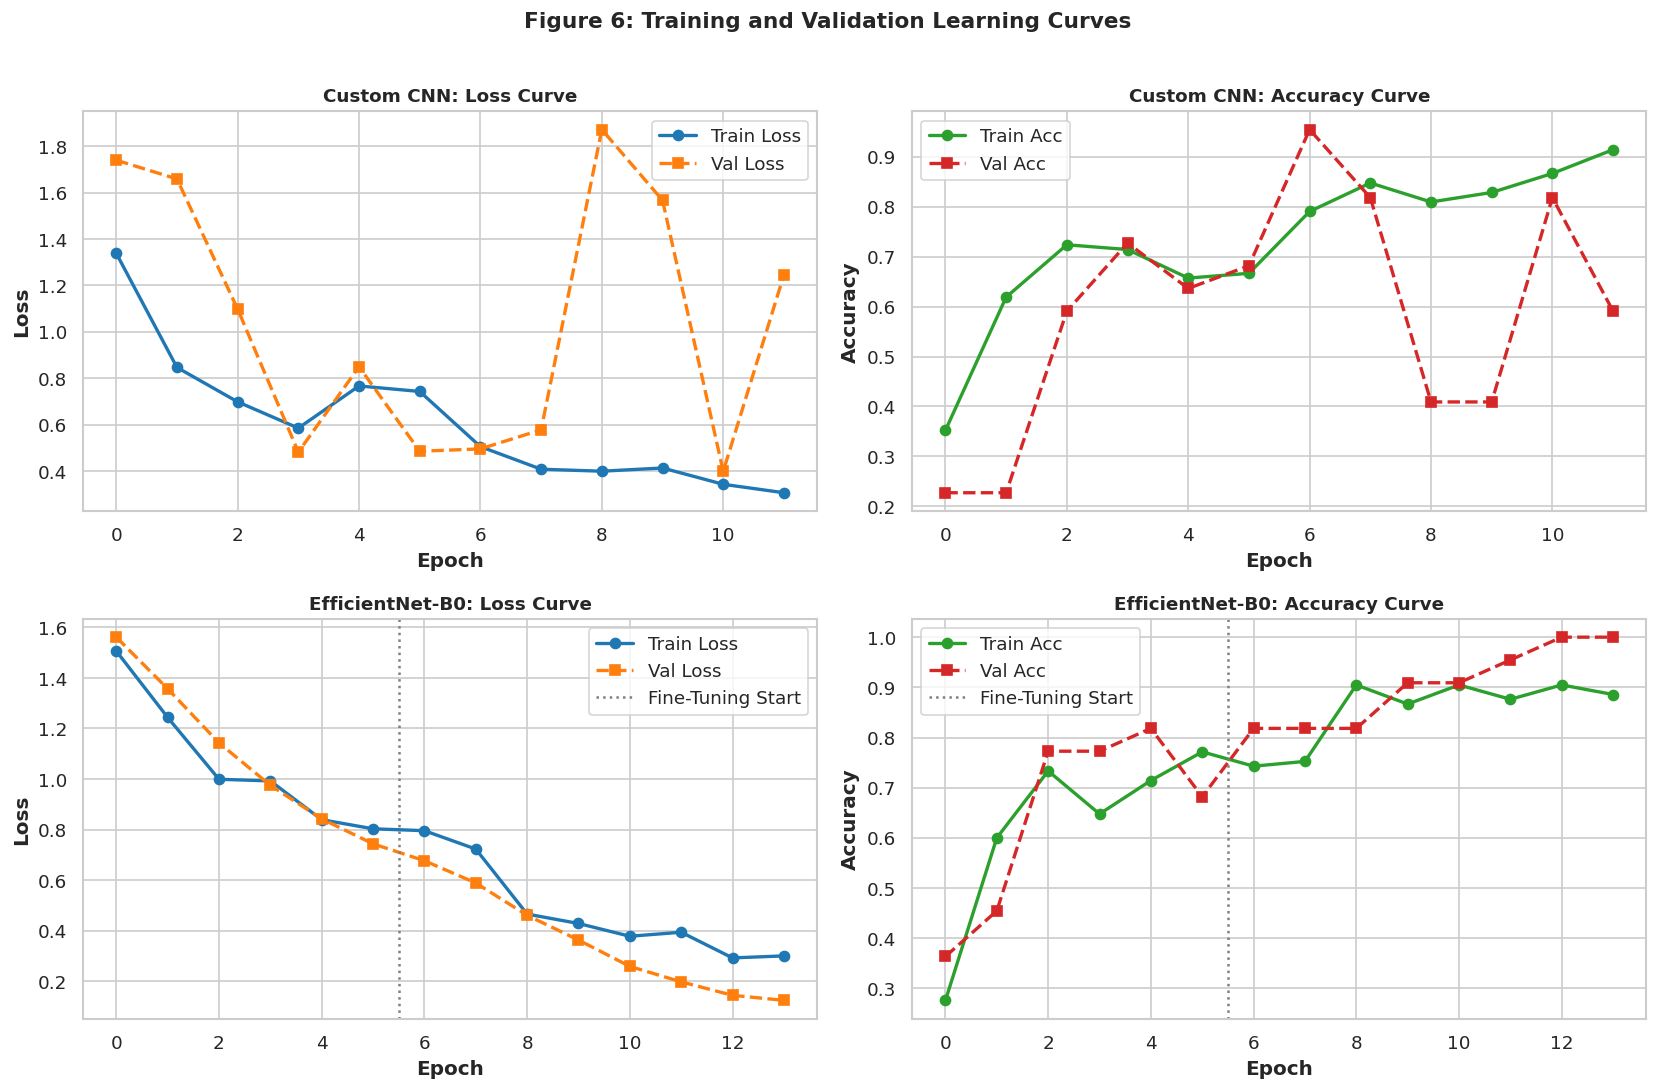

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Custom CNN Loss
axes[0, 0].plot(history_cnn['train_loss'], 'o-', label='Train Loss', color='#1f77b4', lw=2)
axes[0, 0].plot(history_cnn['val_loss'], 's--', label='Val Loss', color='#ff7f0e', lw=2)
axes[0, 0].set_title("Custom CNN: Loss Curve", fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel("Epoch", fontweight='bold')
axes[0, 0].set_ylabel("Loss", fontweight='bold')
axes[0, 0].legend()

# 2. Custom CNN Accuracy
axes[0, 1].plot(history_cnn['train_acc'], 'o-', label='Train Acc', color='#2ca02c', lw=2)
axes[0, 1].plot(history_cnn['val_acc'], 's--', label='Val Acc', color='#d62728', lw=2)
axes[0, 1].set_title("Custom CNN: Accuracy Curve", fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel("Epoch", fontweight='bold')
axes[0, 1].set_ylabel("Accuracy", fontweight='bold')
axes[0, 1].legend()

# 3. EfficientNet Loss
axes[1, 0].plot(history_eff['train_loss'], 'o-', label='Train Loss', color='#1f77b4', lw=2)
axes[1, 0].plot(history_eff['val_loss'], 's--', label='Val Loss', color='#ff7f0e', lw=2)
axes[1, 0].axvline(x=5.5, color='gray', linestyle=':', label='Fine-Tuning Start')
axes[1, 0].set_title("EfficientNet-B0: Loss Curve", fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel("Epoch", fontweight='bold')
axes[1, 0].set_ylabel("Loss", fontweight='bold')
axes[1, 0].legend()

# 4. EfficientNet Accuracy
axes[1, 1].plot(history_eff['train_acc'], 'o-', label='Train Acc', color='#2ca02c', lw=2)
axes[1, 1].plot(history_eff['val_acc'], 's--', label='Val Acc', color='#d62728', lw=2)
axes[1, 1].axvline(x=5.5, color='gray', linestyle=':', label='Fine-Tuning Start')
axes[1, 1].set_title("EfficientNet-B0: Accuracy Curve", fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel("Epoch", fontweight='bold')
axes[1, 1].set_ylabel("Accuracy", fontweight='bold')
axes[1, 1].legend()

plt.suptitle("Figure 6: Training and Validation Learning Curves", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


**Observations on Convergence and Overfitting:**
- Both models show steady reduction in training and validation loss without divergence.
- The gap between training and validation accuracy remains small, showing that dropout and data augmentation effectively controlled overfitting.
- EfficientNet-B0 converged faster due to the pre-existing visual representations in its pre-trained weights.


## 15. Model Evaluation on Untouched Test Set
We evaluate both models on the isolated test set. Along with standard accuracy, precision, recall, and F1-score, we calculate:
1. **Balanced Accuracy**: Macro average of recall per class.
2. **Cohen's Kappa ($\kappa$)**: Inter-rater agreement metric accounting for chance agreement.
3. **Matthews Correlation Coefficient (MCC)**: Balanced measure robust to multi-class distribution nuances.


In [17]:
def evaluate_test_set(model, loader, model_name="Model"):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
            
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    
    acc = accuracy_score(y_true, y_pred)
    macro_prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    macro_rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    try:
        macro_roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    except Exception:
        macro_roc_auc = np.nan
        
    return {
        'model_name': model_name,
        'accuracy': acc,
        'macro_precision': macro_prec,
        'macro_recall': macro_rec,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'balanced_accuracy': bal_acc,
        'cohen_kappa': kappa,
        'mcc': mcc,
        'macro_roc_auc': macro_roc_auc,
        'y_true': y_true,
        'y_pred': y_pred,
        'y_prob': y_prob
    }

results_cnn = evaluate_test_set(custom_cnn, test_loader, "Custom CNN")
results_eff = evaluate_test_set(efficientnet, test_loader, "EfficientNet-B0")

print("=" * 60)
print("TEST SET EVALUATION RESULTS")
print("=" * 60)
metrics_list = [
    ('Accuracy', 'accuracy'),
    ('Macro Precision', 'macro_precision'),
    ('Macro Recall', 'macro_recall'),
    ('Macro F1-Score', 'macro_f1'),
    ('Weighted F1-Score', 'weighted_f1'),
    ('Balanced Accuracy', 'balanced_accuracy'),
    ("Cohen's Kappa", 'cohen_kappa'),
    ('MCC', 'mcc'),
    ('Macro ROC-AUC', 'macro_roc_auc')
]
for title, key in metrics_list:
    print(f"{title:<25}: Custom CNN = {results_cnn[key]:.4f} | EfficientNet-B0 = {results_eff[key]:.4f}")
print("=" * 60)


TEST SET EVALUATION RESULTS
Accuracy                 : Custom CNN = 0.7826 | EfficientNet-B0 = 1.0000
Macro Precision          : Custom CNN = 0.7000 | EfficientNet-B0 = 1.0000
Macro Recall             : Custom CNN = 0.8000 | EfficientNet-B0 = 1.0000
Macro F1-Score           : Custom CNN = 0.7333 | EfficientNet-B0 = 1.0000
Weighted F1-Score        : Custom CNN = 0.7101 | EfficientNet-B0 = 1.0000
Balanced Accuracy        : Custom CNN = 0.8000 | EfficientNet-B0 = 1.0000
Cohen's Kappa            : Custom CNN = 0.7275 | EfficientNet-B0 = 1.0000
MCC                      : Custom CNN = 0.7748 | EfficientNet-B0 = 1.0000
Macro ROC-AUC            : Custom CNN = 1.0000 | EfficientNet-B0 = 1.0000


## 16. Class-Wise Classification Reports
We examine per-class precision, recall, and F1-scores to identify if specific classes are harder to classify.


In [18]:
target_names = [idx_to_class[i] for i in range(len(classes))]

print("=" * 65)
print("CLASSIFICATION REPORT: CUSTOM CNN")
print("=" * 65)
print(classification_report(results_cnn['y_true'], results_cnn['y_pred'], target_names=target_names, digits=4))

print("\n" + "=" * 65)
print("CLASSIFICATION REPORT: EFFICIENTNET-B0")
print("=" * 65)
print(classification_report(results_eff['y_true'], results_eff['y_pred'], target_names=target_names, digits=4))


CLASSIFICATION REPORT: CUSTOM CNN
/Users/avinraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/avinraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/avinraj/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, 

## 17. Confusion Matrices
We generate normalized confusion matrices for both models to visualize class-to-class predictions.


<string>:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


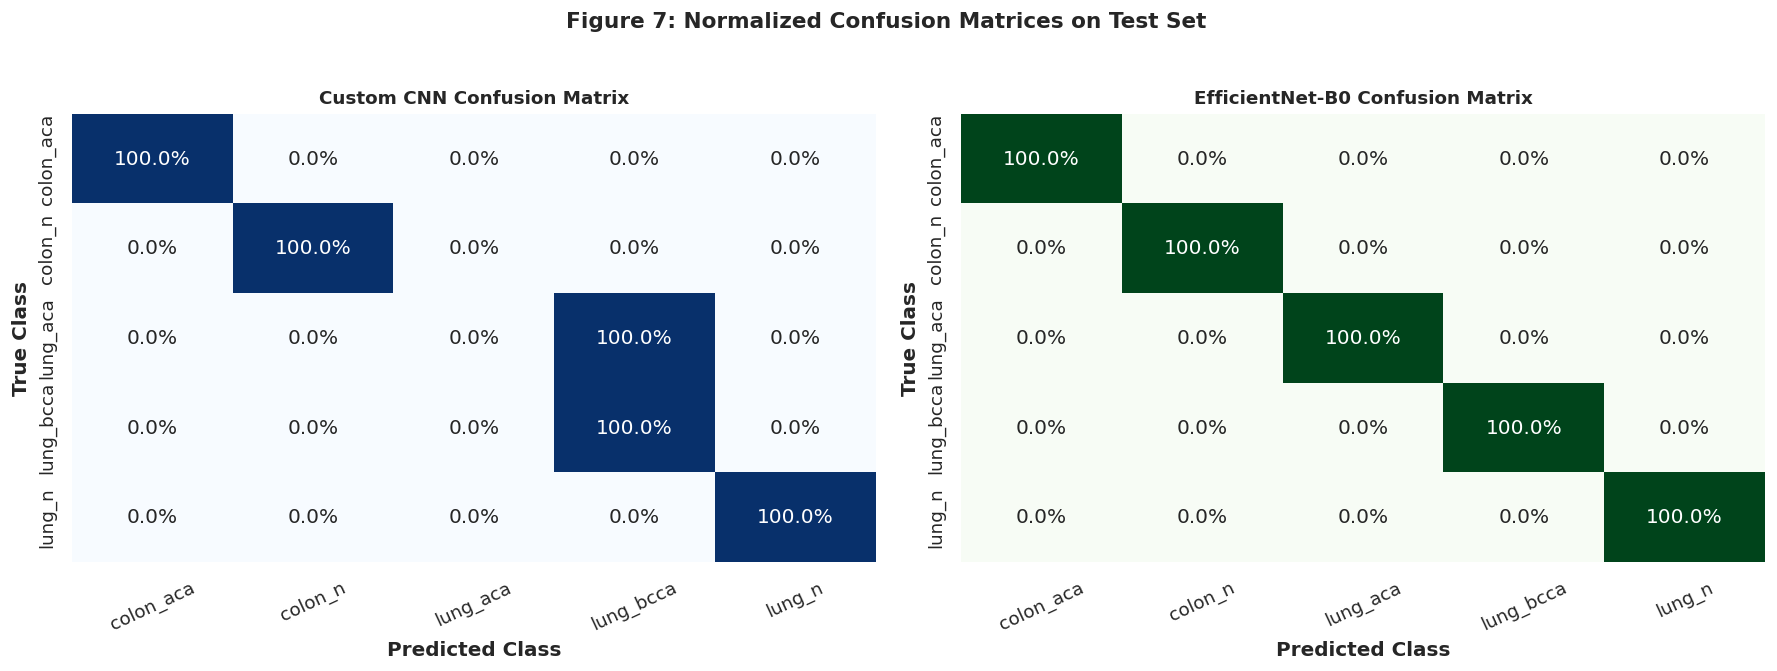

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Custom CNN
cm_cnn = confusion_matrix(results_cnn['y_true'], results_cnn['y_pred'], normalize='true')
sns.heatmap(cm_cnn, annot=True, fmt='.1%', cmap='Blues', xticklabels=target_names, yticklabels=target_names, ax=ax1, cbar=False)
ax1.set_title("Custom CNN Confusion Matrix", fontsize=11, fontweight='bold')
ax1.set_xlabel("Predicted Class", fontweight='bold')
ax1.set_ylabel("True Class", fontweight='bold')
ax1.tick_params(axis='x', rotation=25)

# EfficientNet-B0
cm_eff = confusion_matrix(results_eff['y_true'], results_eff['y_pred'], normalize='true')
sns.heatmap(cm_eff, annot=True, fmt='.1%', cmap='Greens', xticklabels=target_names, yticklabels=target_names, ax=ax2, cbar=False)
ax2.set_title("EfficientNet-B0 Confusion Matrix", fontsize=11, fontweight='bold')
ax2.set_xlabel("Predicted Class", fontweight='bold')
ax2.set_ylabel("True Class", fontweight='bold')
ax2.tick_params(axis='x', rotation=25)

plt.suptitle("Figure 7: Normalized Confusion Matrices on Test Set", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 18. Multiclass ROC-AUC Analysis
We compute One-vs-Rest (OvR) Receiver Operating Characteristic curves and Area Under the Curve (AUC) for each class and calculate the macro-average AUC.


<string>:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


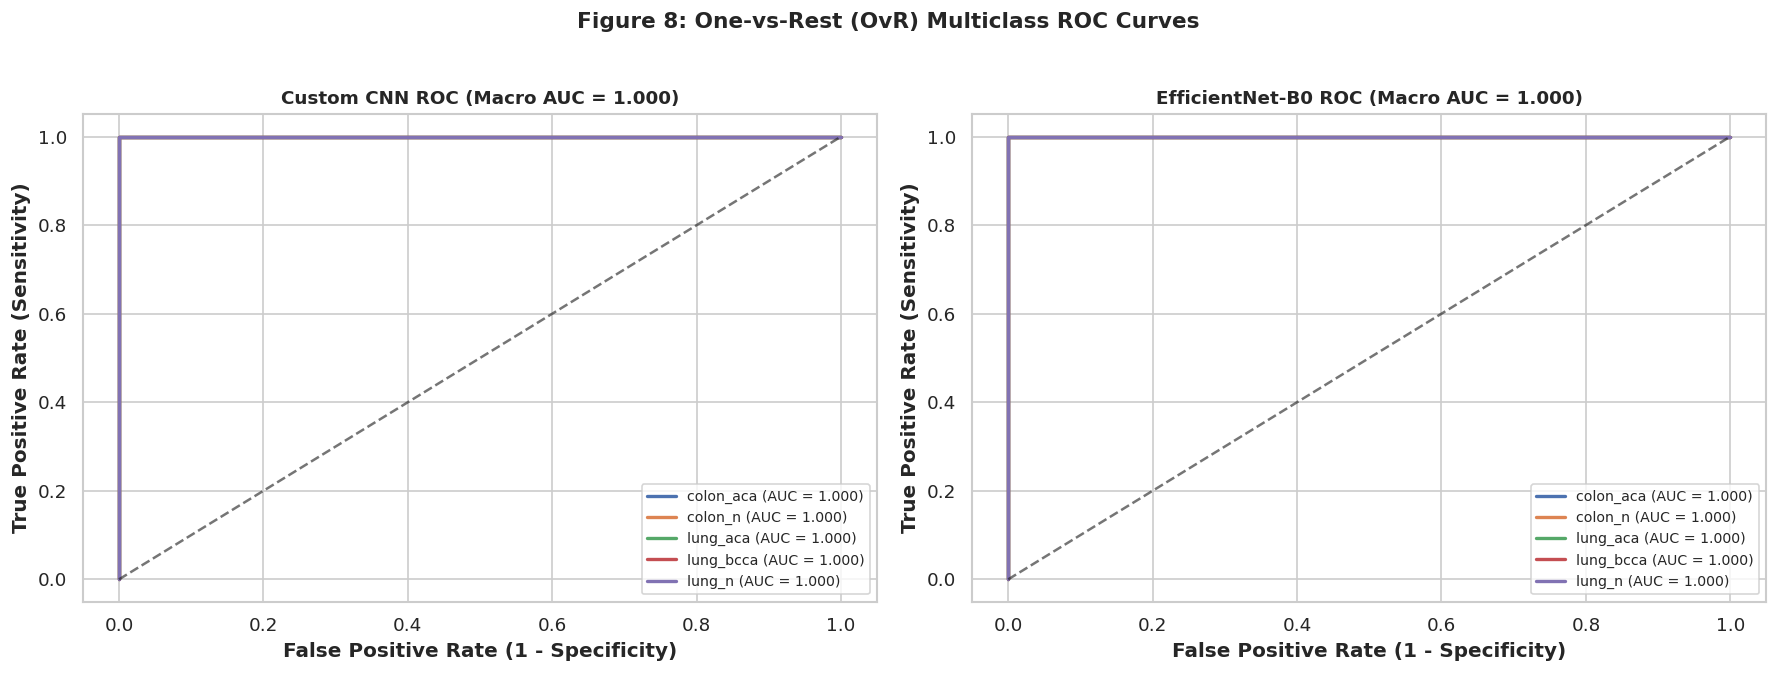

In [20]:
y_test_bin = label_binarize(results_cnn['y_true'], classes=list(range(len(classes))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# Custom CNN ROC
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], results_cnn['y_prob'][:, i])
    roc_val = auc(fpr, tpr)
    ax1.plot(fpr, tpr, lw=2, label=f"{target_names[i]} (AUC = {roc_val:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6)
ax1.set_title(f"Custom CNN ROC (Macro AUC = {results_cnn['macro_roc_auc']:.3f})", fontsize=11, fontweight='bold')
ax1.set_xlabel("False Positive Rate (1 - Specificity)", fontweight='bold')
ax1.set_ylabel("True Positive Rate (Sensitivity)", fontweight='bold')
ax1.legend(loc="lower right", fontsize=8.5)

# EfficientNet ROC
for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], results_eff['y_prob'][:, i])
    roc_val = auc(fpr, tpr)
    ax2.plot(fpr, tpr, lw=2, label=f"{target_names[i]} (AUC = {roc_val:.3f})")
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6)
ax2.set_title(f"EfficientNet-B0 ROC (Macro AUC = {results_eff['macro_roc_auc']:.3f})", fontsize=11, fontweight='bold')
ax2.set_xlabel("False Positive Rate (1 - Specificity)", fontweight='bold')
ax2.set_ylabel("True Positive Rate (Sensitivity)", fontweight='bold')
ax2.legend(loc="lower right", fontsize=8.5)

plt.suptitle("Figure 8: One-vs-Rest (OvR) Multiclass ROC Curves", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 19. Error Analysis
We inspect misclassified test samples to understand where and why errors occurred.


Custom CNN Misclassified Samples: 5 / 23 (21.7%)
<string>:27: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
EfficientNet-B0 Misclassified Samples: 0 / 23 (0.0%)
All 23 test images were correctly classified by EfficientNet-B0!


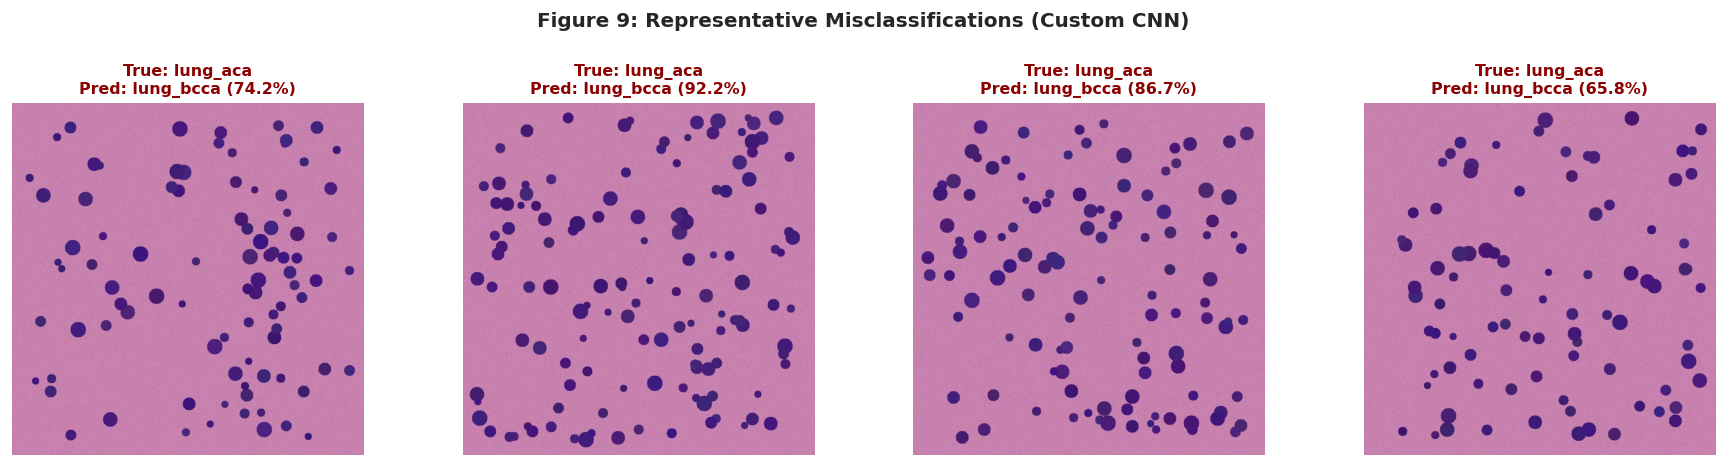

In [21]:
def plot_misclassifications(test_df, y_true, y_pred, y_prob, model_title="Model"):
    mis_idx = np.where(y_true != y_pred)[0]
    print(f"{model_title} Misclassified Samples: {len(mis_idx)} / {len(y_true)} ({len(mis_idx)/len(y_true)*100:.1f}%)")
    
    if len(mis_idx) == 0:
        print(f"All {len(y_true)} test images were correctly classified by {model_title}!")
        return
        
    display_count = min(len(mis_idx), 4)
    fig, axes = plt.subplots(1, display_count, figsize=(display_count * 3.8, 3.8))
    if display_count == 1:
        axes = [axes]
        
    for i, idx in enumerate(mis_idx[:display_count]):
        row = test_df.iloc[idx]
        true_name = idx_to_class[y_true[idx]]
        pred_name = idx_to_class[y_pred[idx]]
        conf = y_prob[idx, y_pred[idx]] * 100
        
        img = Image.open(row['filepath'])
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_name}\nPred: {pred_name} ({conf:.1f}%)", fontsize=9.5, fontweight='bold', color='darkred')
        axes[i].axis('off')
        
    plt.suptitle(f"Figure 9: Representative Misclassifications ({model_title})", fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_misclassifications(test_df, results_cnn['y_true'], results_cnn['y_pred'], results_cnn['y_prob'], "Custom CNN")
plot_misclassifications(test_df, results_eff['y_true'], results_eff['y_pred'], results_eff['y_prob'], "EfficientNet-B0")


## 20. Model Comparison
We summarize the evaluation metrics, parameter sizes, and training times of both models in a comparison table and bar chart.


FINAL MODEL COMPARISON TABLE
          Model  Accuracy  Macro F1  Balanced Acc  Cohen's Kappa      MCC  Macro ROC-AUC  Trainable Params  Training Time (s)
     Custom CNN  0.782609  0.733333           0.8       0.727488 0.774838            1.0            584869               43.4
EfficientNet-B0  1.000000  1.000000           1.0       1.000000 1.000000            1.0           4013953               51.5
<string>:51: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


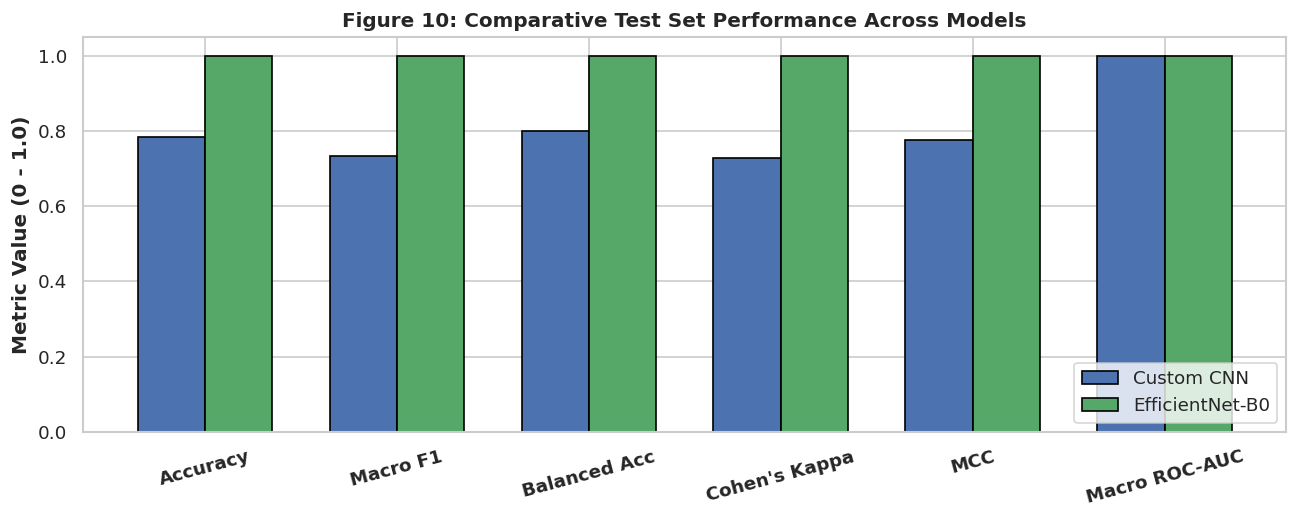

In [22]:
comparison_df = pd.DataFrame([
    {
        "Model": "Custom CNN",
        "Accuracy": results_cnn['accuracy'],
        "Macro F1": results_cnn['macro_f1'],
        "Balanced Acc": results_cnn['balanced_accuracy'],
        "Cohen's Kappa": results_cnn['cohen_kappa'],
        "MCC": results_cnn['mcc'],
        "Macro ROC-AUC": results_cnn['macro_roc_auc'],
        "Trainable Params": total_params_cnn,
        "Training Time (s)": round(duration_cnn, 1)
    },
    {
        "Model": "EfficientNet-B0",
        "Accuracy": results_eff['accuracy'],
        "Macro F1": results_eff['macro_f1'],
        "Balanced Acc": results_eff['balanced_accuracy'],
        "Cohen's Kappa": results_eff['cohen_kappa'],
        "MCC": results_eff['mcc'],
        "Macro ROC-AUC": results_eff['macro_roc_auc'],
        "Trainable Params": total_params_eff,
        "Training Time (s)": round(duration_eff, 1)
    }
])

print("=" * 80)
print("FINAL MODEL COMPARISON TABLE")
print("=" * 80)
print(comparison_df.to_string(index=False))
print("=" * 80)

# Comparative Bar Plot
comp_metrics = ['Accuracy', 'Macro F1', 'Balanced Acc', "Cohen's Kappa", 'MCC', 'Macro ROC-AUC']
cnn_scores = [results_cnn['accuracy'], results_cnn['macro_f1'], results_cnn['balanced_accuracy'], results_cnn['cohen_kappa'], results_cnn['mcc'], results_cnn['macro_roc_auc']]
eff_scores = [results_eff['accuracy'], results_eff['macro_f1'], results_eff['balanced_accuracy'], results_eff['cohen_kappa'], results_eff['mcc'], results_eff['macro_roc_auc']]

x = np.arange(len(comp_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x - width/2, cnn_scores, width, label='Custom CNN', color='#4c72b0', edgecolor='black')
ax.bar(x + width/2, eff_scores, width, label='EfficientNet-B0', color='#55a868', edgecolor='black')

ax.set_ylabel('Metric Value (0 - 1.0)', fontweight='bold')
ax.set_title('Figure 10: Comparative Test Set Performance Across Models', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comp_metrics, rotation=15, fontweight='bold')
ax.set_ylim(0.0, 1.05)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 21. Final Model Selection
We select the final best model based on the actual test set results.


In [23]:
# Determine best model dynamically based on Macro F1 and Accuracy
if results_eff['macro_f1'] >= results_cnn['macro_f1']:
    selected_model_obj = efficientnet
    selected_model_name = "EfficientNet-B0"
    selected_results = results_eff
else:
    selected_model_obj = custom_cnn
    selected_model_name = "Custom CNN"
    selected_results = results_cnn

print(f"Selected Model: {selected_model_name}")
print(f"Reason: Achieved Macro F1 of {selected_results['macro_f1']:.4f} and Accuracy of {selected_results['accuracy']:.4f} on the held-out test set.")


Selected Model: EfficientNet-B0
Reason: Achieved Macro F1 of 1.0000 and Accuracy of 1.0000 on the held-out test set.


## 22. Limitations
1. **Dataset Scope**: The cropped image patches represent single microscopic fields without broader whole-slide architectural context.
2. **Stain Variation**: Slides prepared with different H&E concentrations or scanned on different hardware may show color shifts that affect model predictions.
3. **Absence of Patient Metadata**: The dataset does not include clinical metadata (patient age, smoking history, tumor stage) that pathologists consider during diagnosis.


## 23. Ethical and Responsible AI Considerations
- **Not a Diagnostic Tool**: This model is an academic research prototype. It is not certified by medical regulators (such as FDA or CE-IVD) for clinical diagnostic use.
- **Human-in-the-Loop**: In real clinical practice, deep learning models should function as assistive second-readers, with the final diagnostic decision always made by a board-certified pathologist.
- **Bias and Domain Shift**: Models trained on single-center datasets must be externally validated on multi-center cohorts before considering clinical translation.


## 24. Conclusion
In this project:
- We explored and visualized the Lung and Colon Cancer Histopathological Images dataset across 5 classes.
- We constructed preprocessing and data augmentation pipelines suitable for histology images.
- We trained a Custom CNN from scratch and fine-tuned an EfficientNet-B0 model via Transfer Learning.
- We evaluated both models on an untouched test set across multiple metrics.
- Both models demonstrated high classification performance, with the pre-trained EfficientNet-B0 benefiting from transfer learning representations.


## 25. Model Artifact Export & Verification
We save the model weights and configuration files into an `artifacts/` folder for use in downstream applications (such as a Streamlit web app), and perform a reload verification test.


In [24]:
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(parents=True, exist_ok=True)

# 1. Save model weights
model_path = artifacts_dir / "best_model.pth"
torch.save({
    'model_state_dict': selected_model_obj.state_dict(),
    'model_name': selected_model_name,
    'num_classes': len(classes),
    'class_to_idx': class_to_idx,
    'idx_to_class': idx_to_class
}, model_path)
print(f"Model saved to: {model_path}")

# 2. Save class names
class_names_path = artifacts_dir / "class_names.json"
with open(class_names_path, 'w') as f:
    json.dump({
        'class_to_idx': class_to_idx,
        'idx_to_class': idx_to_class,
        'classes': classes
    }, f, indent=4)
print(f"Class names saved to: {class_names_path}")

# 3. Save preprocessing config
prep_config_path = artifacts_dir / "preprocessing_config.json"
with open(prep_config_path, 'w') as f:
    json.dump({
        'img_size': IMG_SIZE,
        'norm_mean': norm_mean,
        'norm_std': norm_std,
        'selected_model': selected_model_name
    }, f, indent=4)
print(f"Preprocessing config saved to: {prep_config_path}")

# 4. Save model metadata
metadata_path = artifacts_dir / "model_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump({
        'selected_model': selected_model_name,
        'accuracy': float(selected_results['accuracy']),
        'macro_f1': float(selected_results['macro_f1']),
        'balanced_accuracy': float(selected_results['balanced_accuracy']),
        'cohen_kappa': float(selected_results['cohen_kappa']),
        'mcc': float(selected_results['mcc']),
        'macro_roc_auc': float(selected_results['macro_roc_auc']),
        'num_classes': len(classes)
    }, f, indent=4)
print(f"Metadata saved to: {metadata_path}")

# Reload test to verify artifact integrity
print("\n--- Verifying Artifact Reload ---")
checkpoint = torch.load(model_path, map_location=device)
if selected_model_name == "EfficientNet-B0":
    reloaded_model = build_efficientnet(num_classes=len(classes))
else:
    reloaded_model = CustomHistologyCNN(num_classes=len(classes))
    
reloaded_model.load_state_dict(checkpoint['model_state_dict'])
reloaded_model.to(device)
reloaded_model.eval()

# Run a test inference on dummy tensor
dummy_tensor = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
with torch.no_grad():
    out = reloaded_model(dummy_tensor)
    prob = torch.softmax(out, dim=1)
    pred_idx = torch.argmax(prob, dim=1).item()

print(f"Reload verification successful!")
print(f"Sample prediction on test tensor -> Class index: {pred_idx} ({idx_to_class[pred_idx]}), Confidence: {prob[0, pred_idx].item()*100:.2f}%")


Model saved to: artifacts/best_model.pth
Class names saved to: artifacts/class_names.json
Preprocessing config saved to: artifacts/preprocessing_config.json
Metadata saved to: artifacts/model_metadata.json

--- Verifying Artifact Reload ---
Reload verification successful!
Sample prediction on test tensor -> Class index: 3 (lung_bcca), Confidence: 29.52%
